In [1]:
# Ensure working directory to project code folder
import os

os.chdir("/ceph/behrens/peter_doohan/goalNav_mFC/experiment/code")
print("Current Working Directory: ", os.getcwd())

from importlib import reload

Current Working Directory:  /ceph/behrens/peter_doohan/goalNav_mFC/experiment/code


In [2]:
# configure matplotlib settings

from matplotlib import pyplot as plt

plt.rcParams.update(
    {
        "font.size": 12,
        "axes.titlesize": 16,
        "axes.labelsize": 14,
        "xtick.labelsize": 14,
        "ytick.labelsize": 14,
        "legend.fontsize": 8,
        "figure.titlesize": 18,
        "pdf.fonttype": 42,
    }
)
from matplotlib.gridspec import GridSpec

### Plots for main text figure

In [3]:
from GridMaze.analysis.core import get_clusters as gc
from GridMaze.analysis.cluster_tuning import events
from GridMaze.maze import plotting as mp
from GridMaze.maze import representations as mr

In [4]:
reload(gc)
reload(events)
reload(mp)


def plot_single_unit_figs(cluster_unique_ID, save_label=False):
    """
    Plots the average and goal-stratified trial aligned tuning curves for a given cluster,
    with maze color key (returns separate figs that can be saved separately) and assembled
    into full figure.
    """
    Cluster = gc.get_cluster(cluster_unique_ID)
    f1, ax1 = plt.subplots(1, 1, figsize=(1.5, 0.5), clear=True)
    Cluster.plot_tuning(feature="trial_events", feature_kwargs={"goal_stratified": False, "color": "black"}, ax=ax1)
    ax1.set_xticklabels([])
    ax1.set_ylabel("Hz")

    f2, ax2 = plt.subplots(1, 1, figsize=(6, 2), clear=True)
    Cluster.plot_tuning(feature="trial_events", feature_kwargs={"goal_stratified": True}, ax=ax2)

    goals = Cluster.goals
    simple_maze = mr.get_simple_maze(Cluster.maze_name)
    f3, ax3 = plt.subplots(1, 1, figsize=(1.5, 1.5), clear=True)
    mp.plot_maze_legend(simple_maze, goals, ax=ax3)

    if save_label:
        f1.savefig(f"../results/goal_coding/example_clusters/{save_label}_inset.pdf")
        f2.savefig(f"../results/goal_coding/example_clusters/{save_label}_tuning.pdf")
        f3.savefig(f"../results/goal_coding/example_clusters/{save_label}_legend.pdf")
    else:
        return f1, f2, f3

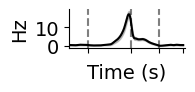

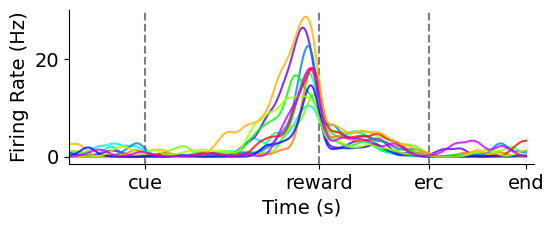

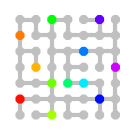

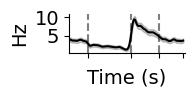

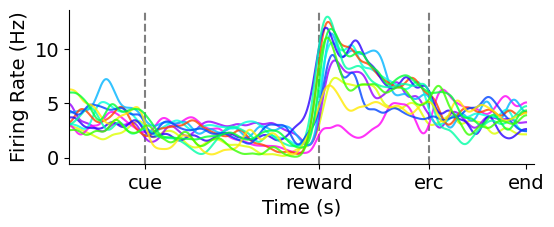

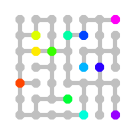

In [ ]:
plot_single_unit_figs("m2.2022-07-04.maze_cluster65", save_label="cluster_1")
plot_single_unit_figs("m3.2022-07-17.maze_cluster45", save_label="cluster_2")
# plot_single_unit_figs("m2.2022-07-04.maze_cluster114", save_label="cluster_3")
# plot_single_unit_figs("m2.2022-07-17.maze_cluster50", save_label="cluster_4")
# plot_single_unit_figs("m6.2022-07-05.maze_cluster134", save_label="cluster_5")

T-statistic: 8.1789
P-value: 0.0004
Degrees of freedom: 5


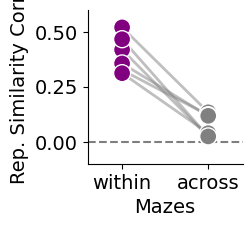

In [7]:
# Load data
from GridMaze.analysis.event_aligned import allocentric_goal_decoding as agd
from GridMaze.analysis.event_aligned import delta_distance_to_goal as ddg
from GridMaze.analysis.event_aligned import reward_time_reps as rtr

RSM_comparisons_df = rtr.get_within_across_maze_RSM_comparison(
    maze_names=["maze_1", "maze_2"],  # rooms_maze
    alignment="event",
    window=(-0.25, 0.25),
)
# show stats
rtr.plot_RDM_comparisons(RSM_comparisons_df, print_stats=True)

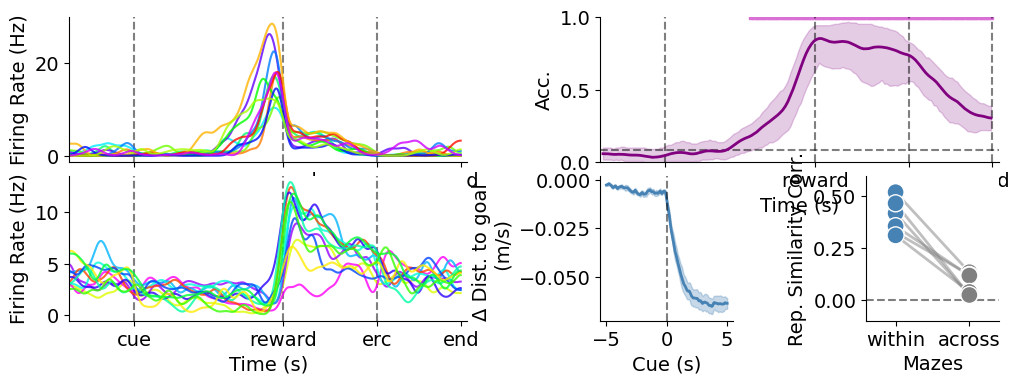

In [8]:
# plot summary figure
reload(agd)
reload(ddg)
reload(rtr)

fig = plt.figure(figsize=(12, 6), clear=True)
gsc = GridSpec(6, 4, figure=fig)
# asign axes
ax1 = fig.add_subplot(gsc[0:2, 0:2])  # example cluster 1
ax2 = fig.add_subplot(gsc[2:4, 0:2])  # example cluster 2
ax3 = fig.add_subplot(gsc[0:2, 2:4])  # goal decoding
ax4 = fig.add_subplot(gsc[2:4, 2])  # rate of change of distance to goal
ax5 = fig.add_subplot(gsc[2:4, 3])  # reward rep sim

# plot single units
cluster_1 = gc.get_cluster("m2.2022-07-04.maze_cluster65")
cluster_2 = gc.get_cluster("m3.2022-07-17.maze_cluster45")
cluster_1.plot_tuning(feature="trial_events", feature_kwargs={"goal_stratified": True}, ax=ax1)
cluster_2.plot_tuning(feature="trial_events", feature_kwargs={"goal_stratified": True}, ax=ax2)

# plot goal decoding
representiative_dataset = ("maze_1", "subset_2")
agd.plot_goal_decoding(
    datasets=[representiative_dataset],
    alignment="trial",
    decoder="logreg",
    bootstrap_method="input",
    ax=ax3,
)

# plot ddtg
ddg.plot_cross_subject_rate_of_change_of_distance_to_goal(ax=ax4, window_length=5, smooth_SD=6, color="steelblue")

# plot rewards sim
rtr.plot_RDM_comparisons(RSM_comparisons_df, ax=ax5, color="steelblue")

fig.subplots_adjust(wspace=1.0)

fig.savefig("../results/goal_coding/decoding_summary.pdf")

## Plots for extended data figure 

Missing results for some subjects: {'m7'}
Missing results for some subjects: {'m7'}


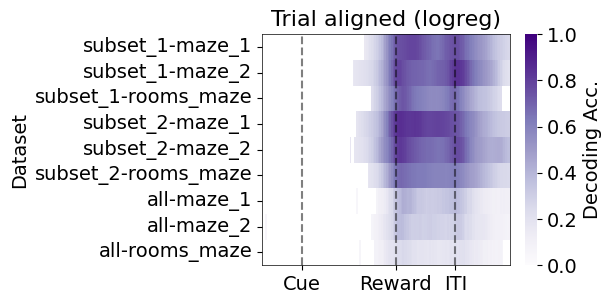

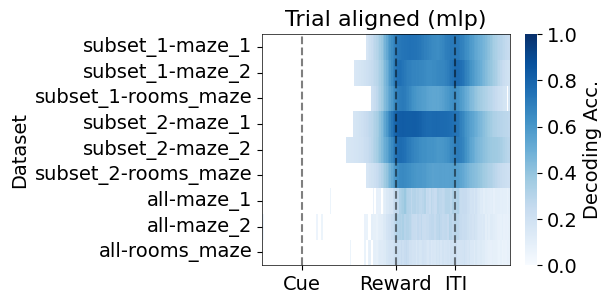

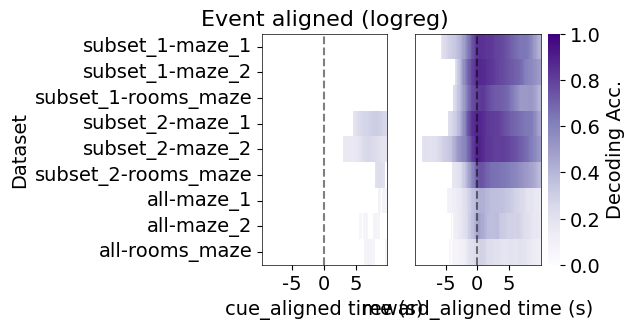

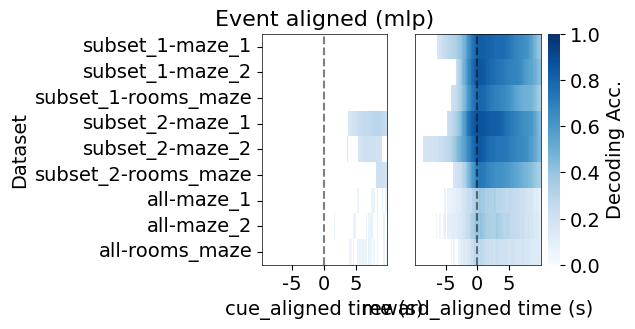

In [11]:
# quick(er) summary plots of goal decoding analyses
from GridMaze.analysis.event_aligned import allocentric_goal_decoding as agd

reload(agd)

f_s1, ax_s1 = plt.subplots(1, 1, figsize=(4, 3), clear=True)
agd.plot_goal_decoding_heatmap_summary(alignment="trial", decoder="logreg", cmap="Purples", ax=ax_s1)
ax_s1.set_title("Trial aligned (logreg)")
f_s1.savefig("../results/goal_coding/decoding_summary_trial-aligned_logreg.pdf")

f_s2, ax_s2 = plt.subplots(1, 1, figsize=(4, 3), clear=True)
agd.plot_goal_decoding_heatmap_summary(alignment="trial", decoder="mlp_torch", cmap="Blues", ax=ax_s2)
ax_s2.set_title("Trial aligned (mlp)")
f_s2.savefig("../results/goal_coding/decoding_summary_trial-aligned_mlp.pdf")

f_s3, axes_s3 = plt.subplots(1, 2, figsize=(4, 3), clear=True, width_ratios=[0.8, 1])
agd.plot_goal_decoding_heatmap_summary(alignment="event", decoder="logreg", cmap="Purples", ax=axes_s3)
axes_s3[0].set_title("Event aligned (logreg)")
f_s3.savefig("../results/goal_coding/decoding_summary_event-aligned_logreg.pdf")

f_s4, axes_s4 = plt.subplots(1, 2, figsize=(4, 3), clear=True, width_ratios=[0.8, 1])
agd.plot_goal_decoding_heatmap_summary(alignment="event", decoder="mlp_torch", cmap="Blues", ax=axes_s4)
axes_s4[0].set_title("Event aligned (mlp)")
f_s4.savefig("../results/goal_coding/decoding_summary_event-aligned_mlp.pdf")

In [ ]:
# plot session level (no pseudo-trial combination across sessions) for completeness
from GridMaze.analysis.distance_to_goal import gd2  # update import later

In [21]:
reload(gd2)
cue_results_df = gd2.get_aligned_decoding(reference="cue", verbose=False)
reward_results_df = gd2.get_aligned_decoding(reference="reward", verbose=False)

frames.navigation.parquet not found for m8.2022-07-26.maze
frames.spikeCounts.parquet not found for m8.2022-07-26.maze
frames.navigation.parquet not found for m8.2022-07-26.maze
frames.spikeCounts.parquet not found for m8.2022-07-26.maze


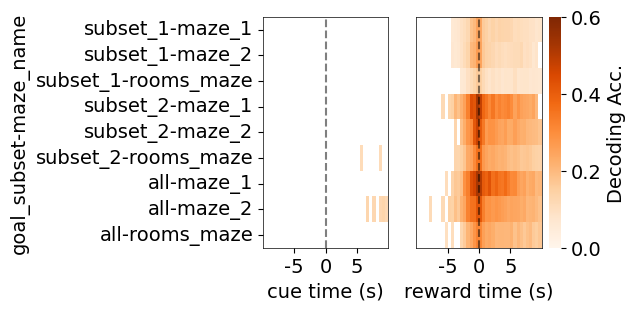

In [33]:
reload(gd2)
f_s5, axes_s5 = plt.subplots(1, 2, figsize=(4, 3), clear=True, width_ratios=[0.8, 1])
gd2.plot_event_aligned_decoding_heatmap_summary(cue_results_df, reward_results_df, axes=axes_s5)
f_s5.savefig("../results/goal_coding/single_session_goal_decoding_summary.pdf")

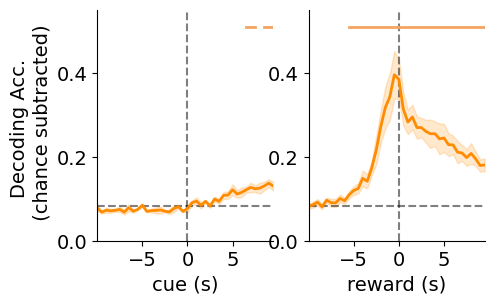

In [34]:
# plot example single sessions decoding results for subset_2

reload(gd2)
f_s6, axes_s6 = plt.subplots(1, 2, figsize=(5, 3), clear=True)
gd2.plot_event_aligned_results(cue_results_df[cue_results_df.goal_subset == "subset_2"], event="cue", ax=axes_s6[0])
gd2.plot_event_aligned_results(
    reward_results_df[reward_results_df.goal_subset == "subset_2"], event="reward", ax=axes_s6[1]
)
axes_s6[1].set_ylabel("")
f_s6.savefig("../results/goal_coding/decoding_example_single_session.pdf")

In [64]:
# plot locomotion controlled version of reward rep sim analysis
reload(rtr)
RSM_comparisons_df2 = rtr.get_within_across_maze_RSM_comparison(
    maze_names=["maze_1", "maze_2"],  # rooms_maze
    alignment="trial",
    window=(0, 1),
)

T-statistic: 3.9835
P-value: 0.0105
Degrees of freedom: 5


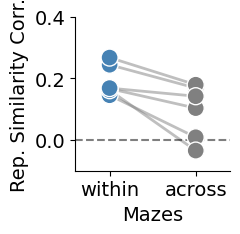

In [ ]:
reload(rtr)
f_s5, ax_s5 = plt.subplots(figsize=(2, 2))
rtr.plot_RDM_comparisons(RSM_comparisons_df2, color="steelblue", print_stats=True, ymax=0.4, ax=ax_s5)
ax_s5.savefig("../results/goal_coding/reward_rep_sim_locomotion_controlled.pdf")